In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap 
#import janitor
import warnings
warnings.filterwarnings('ignore')

In [135]:
#Load the dataset 

df = pd.read_csv('datasets/test.csv')

In [136]:
#Basic check to see how the data is structured

df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [137]:
#Basic check to see how the dat is structured

df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
49995,0x25fe5,CUS_0x8600,December,Sarah McBridec,4975,031-35-0942,Architect,20002.88,1929.906667,10,...,12.0,_,3571.7,34.780553,NaN,Yes,60.964772,146.48632477751087,Low_spent_Small_value_payments,275.53956951573343
49996,0x25fee,CUS_0x942c,September,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.44299902757518,Low_spent_Small_value_payments,409.39456169535066
49997,0x25fef,CUS_0x942c,October,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,__10000__,Low_spent_Large_value_payments,349.7263321025098
49998,0x25ff0,CUS_0x942c,November,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.59857973344877,High_spent_Small_value_payments,463.23898098947717
49999,0x25ff1,CUS_0x942c,December,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,_,502.38,34.108530,32 Years and 2 Months,No,35.104023,220.45787812168732,Low_spent_Medium_value_payments,360.37968260123847


In [138]:
#Check the data type of each column

df.dtypes

ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
dtype: object

In [139]:
#Count of unique values in each column

df.nunique()

ID                          50000
Customer_ID                 12500
Month                           4
Name                        10139
Age                           976
SSN                         12501
Occupation                     16
Annual_Income               16121
Monthly_Inhand_Salary       12793
Num_Bank_Accounts             540
Num_Credit_Card               819
Interest_Rate                 945
Num_of_Loan                   263
Type_of_Loan                 6260
Delay_from_due_date            73
Num_of_Delayed_Payment        443
Changed_Credit_Limit         3927
Num_Credit_Inquiries          750
Credit_Mix                      4
Outstanding_Debt            12685
Credit_Utilization_Ratio    50000
Credit_History_Age            399
Payment_of_Min_Amount           3
Total_EMI_per_month         13144
Amount_invested_monthly     45450
Payment_Behaviour               7
Monthly_Balance             49433
dtype: int64

In [140]:
#The general structure and size of the dataset - rows and columns

df.shape

(50000, 27)

In [141]:
#Check for missing values in each column

df.isnull().sum()

ID                             0
Customer_ID                    0
Month                          0
Name                        5015
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5704
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              562
dtype: int64

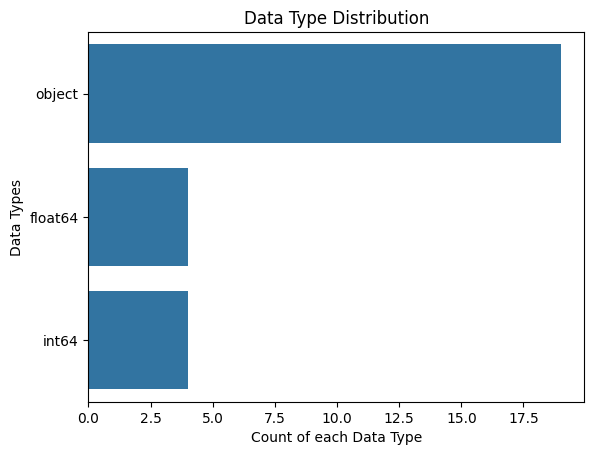

In [142]:
#Plot the distribution of data tytpes - this step is tied to the above step - before diving into cleanig missing values it is important to check for data type distribution so as to determine the best approach

sns.countplot(y=df.dtypes, data=df)
plt.title('Data Type Distribution')
plt.xlabel('Count of each Data Type')
plt.ylabel('Data Types')
plt.show()

In [143]:
#Remove all rows with missing values

df.dropna(axis=0, inplace=True)

In [144]:
#Check to see if there are still any more missing values

df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

In [145]:
#Check to see how the size of the dataset was affected by removing mising values - close to 50% of the rows were removed due to missing data points

df.shape

(26459, 27)

In [146]:
#Categorize columns that do not carry any/much statistical significance and remove them from the dataset

df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Type_of_Loan', 'Occupation'])

df.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,23,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,24,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
4,28,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923
5,28,34847.84,3037.986667,2,4,6,1,3,3,5.42,5.0,Good,605.03,30.116600,27 Years and 4 Months,No,18.816215,251.62736875017606,Low_spent_Large_value_payments,303.3550833433617
7,28,34847.84,3037.986667,2,4,6,1,3,2_,7.42,5.0,_,605.03,33.875167,27 Years and 6 Months,No,18.816215,153.53448761392985,!@9#%8,421.44796447960783


In [147]:
#Categorize numerical columns have been classified as object and not int or float - this suggests that these columns propably contain non numerical characters that need to be removed

strip_columns = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance']

In [148]:
#This step checks the aboove columns and replaces/removes any non-numerical characters that might exists alongside the numerals e.g. 40_ will be reduced to 40

df[strip_columns] = df[strip_columns].replace(r'[^0-9.]', '', regex=True)

In [149]:
#Since foreign have probably been removed, this step, forcefully changes the datatype of object columns to numerical integers or float values - not all columns were included in this step

obj_columns = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance']

df[obj_columns] = df[obj_columns].apply(pd.to_numeric, errors='coerce')

In [150]:
#This step inspects the effects of the forceful type casting in the step above - it can be seen that one column was affected and now has 577 missing values

df.isna().sum()

Age                           0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                   0
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Changed_Credit_Limit        577
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age            0
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly       0
Payment_Behaviour             0
Monthly_Balance               0
dtype: int64

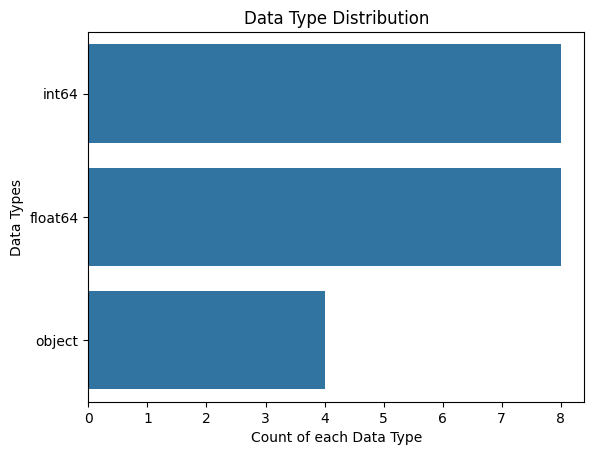

In [151]:
#This step check the new distribution of data types after the steps above steps - it can be seen that most columns are now integers or float values - an indication that the above steps worked.

sns.countplot(y=df.dtypes, data=df)
plt.title('Data Type Distribution')
plt.xlabel('Count of each Data Type')
plt.ylabel('Data Types')

plt.show()

In [152]:
#Since we still have 4 object columns as seen above - further steps will involve specific fixes to individual columns that we are certain should'nt be classified as objects but as numerals

df.dtypes

Age                           int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date           int64
Num_of_Delayed_Payment        int64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age            int64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
dtype: object

In [153]:
# Column 1: Credit_Mix - we check to see the values in this column - and it can be seen that it is an object column but has a foreign character "_" - to be removed.

df.Credit_Mix.unique()

array(['Good', '_', 'Standard', 'Bad'], dtype=object)

In [154]:
# Column 2: It is also an object column but has a non-boolean character "NM" -  to be removed.

df.Payment_of_Min_Amount.unique()

array(['No', 'NM', 'Yes'], dtype=object)

In [155]:
# Column 3: It is also an object column but has unclassified entries "!@9#%8" - to be removed.

df.Payment_Behaviour.unique()

array(['Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Large_value_payments', '!@9#%8',
       'Low_spent_Medium_value_payments',
       'High_spent_Small_value_payments'], dtype=object)

In [156]:
#This step removes the unclassified from Column 3 above.

df = df[df.Payment_Behaviour != "!@9#%8"]

In [157]:
#Check to ascertain that the unclassified entries have been removed from Column 3

df.Payment_Behaviour.unique()

array(['Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'High_spent_Small_value_payments'], dtype=object)

In [158]:
#Check the effect of the above step on the size of the dataset

df.shape

(24423, 20)

In [159]:
#Check for unique values on Column 1 above - it can be see that there are unclassified records with the entry "_"

df.Credit_Mix.unique()

array(['Good', '_', 'Standard', 'Bad'], dtype=object)

In [160]:
#Check to determine how rows have the foreign entry "_"

df.Credit_Mix.value_counts()

Credit_Mix
Standard    9005
Good        5321
Bad         5265
_           4832
Name: count, dtype: int64

In [161]:
#Remove all rows with the foreign character '_'

df = df[df.Credit_Mix != "_"]

In [162]:
#Check to confirm that the foreign character is removed

df.Credit_Mix.value_counts()

Credit_Mix
Standard    9005
Good        5321
Bad         5265
Name: count, dtype: int64

In [163]:
#Check the effect of the above operation on the size of the dataset.

df.shape

(19591, 20)

In [164]:
#Inspection of unique values in column 2 above.

df.Payment_of_Min_Amount.unique()

array(['No', 'NM', 'Yes'], dtype=object)

In [165]:
#Check the value counts of unique values in Column => 2351 rows have a non boolean entry "NM"

df.Payment_of_Min_Amount.value_counts()

Payment_of_Min_Amount
Yes    10968
No      6272
NM      2351
Name: count, dtype: int64

In [166]:
#Remove the 2351 rows that have the non-boolean entry

df = df[df.Payment_of_Min_Amount != "NM"]

In [167]:
#Check that the operation was successful

df.Payment_of_Min_Amount.value_counts()

Payment_of_Min_Amount
Yes    10968
No      6272
Name: count, dtype: int64

In [168]:
#Check the effect of the operation on the size of the dataset.

df.shape

(17240, 20)

In [169]:
#Check for missing values - that might arised from the above operations since the last check.

df.isnull().sum()

Age                           0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                   0
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Changed_Credit_Limit        382
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age            0
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly       0
Payment_Behaviour             0
Monthly_Balance               0
dtype: int64

In [170]:
#Remove the rows with missing values - again!

df.dropna(axis=0, inplace=True)

In [171]:
#Check that there are no more missing values. 

df.isnull().sum()

Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

In [172]:
#Check effect of the operations on the size of the dataset.

df.shape

(16858, 20)

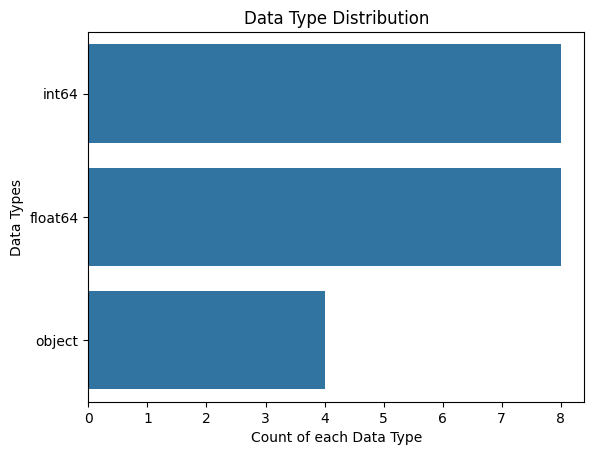

In [173]:
#Check datatype distribution

sns.countplot(y=df.dtypes, data=df)
plt.title('Data Type Distribution')
plt.xlabel('Count of each Data Type')
plt.ylabel('Data Types')
plt.show()

In [174]:
#Visual inspection of the dataset as at this point of preprocessing

df.head(10)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,23,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,Good,809.98,35.030402,229,No,49.574949,236.642682,Low_spent_Small_value_payments,186.266702
1,24,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,Good,809.98,33.053114,2210,No,49.574949,21.465380,High_spent_Medium_value_payments,361.444004
4,28,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,Good,605.03,25.926822,273,No,18.816215,39.684018,High_spent_Large_value_payments,485.298434
5,28,34847.84,3037.986667,2,4,6,1,3,3,5.42,5.0,Good,605.03,30.116600,274,No,18.816215,251.627369,Low_spent_Large_value_payments,303.355083
9,35,143162.64,12187.220000,1,5,8,3,6,3,2.10,3.0,Good,1303.01,35.685836,186,No,246.992319,453.615131,Low_spent_Large_value_payments,788.114550
12,55,30689.89,2612.490833,2,5,4,1,5,6,1.99,4.0,Good,632.46,39.377219,1711,No,16.415452,69.107006,High_spent_Medium_value_payments,425.726626
14,55,30689.89,2612.490833,2,5,4,1,5,6,1.99,4.0,Good,632.46,36.824468,181,No,16.415452,191.886244,Low_spent_Medium_value_payments,332.947388
15,55,4148862.00,2612.490833,2,5,4,1,6,6,1.99,7.0,Good,632.46,35.579265,182,No,16.415452,233.933417,Low_spent_Small_value_payments,300.900215
25,34,131313.40,10469.207759,0,1,8,2,0,2,9.34,4.0,Good,352.16,31.025571,314,No,911.220179,966.074336,Low_spent_Large_value_payments,290.559392
37,45,31370.80,2825.233333,1,6,12,2,2,3,5.76,5.0,Good,421.43,33.854096,272,No,46.616129,109.420763,High_spent_Medium_value_payments,376.486442


In [175]:
#Visual inspection of the dataset as at this point of preprocessing

df.tail(10)

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
49966,39,15319.65,1460.637500,6,7,15,4,53,16,17.13,6.0,Bad,1453.61,25.497671,117,Yes,28.182033,28.514703,High_spent_Large_value_payments,329.367014
49976,21,38321.39,3106.647859,4,4,3,4,11,7,1.59,6.0,Good,678.57,29.004432,177,No,362.072453,79.991128,High_spent_Large_value_payments,381.182642
49981,19,42903.79,3468.315833,1727,4,6,1,14,2,5.10,1.0,Good,1079.48,27.122224,2810,No,34.975457,134.078087,High_spent_Medium_value_payments,427.778040
49988,50,37188.10,3097.008333,1,4,5261,3,7,12,9.38,3.0,Good,620.64,32.740865,305,No,84.205949,165.115322,Low_spent_Small_value_payments,350.379562
49989,50,37188.10,3097.008333,1,4,2658,3,7,12,5.38,3.0,Good,620.64,23.986021,306,No,84.205949,10000.000000,Low_spent_Large_value_payments,270.754039
49990,50,37188.10,3097.008333,1,4,4252,3,7,12,5.38,3.0,Good,620.64,25.708414,307,No,84.205949,183.365628,Low_spent_Large_value_payments,312.129256
49992,29,20002.88,1929.906667,10,8,29,5,33,25,18.31,9.0,Bad,3571.7,32.391288,64,Yes,60.964772,107.210742,Low_spent_Small_value_payments,314.815153
49993,29,20002.88,1929.906667,10,8,29,5,33,25,18.31,12.0,Bad,3571.7,37.528511,65,Yes,60.964772,71.794421,Low_spent_Small_value_payments,350.231473
49994,29,20002.88,1929.906667,10,8,29,5,33,22,18.31,12.0,Bad,3571.7,27.027812,66,Yes,60.964772,50.846847,High_spent_Small_value_payments,341.179047
49997,25,39628.99,3359.415833,4,6,7,2,23,5,13.50,7.0,Good,502.38,36.858542,320,No,35.104023,10000.000000,Low_spent_Large_value_payments,349.726332


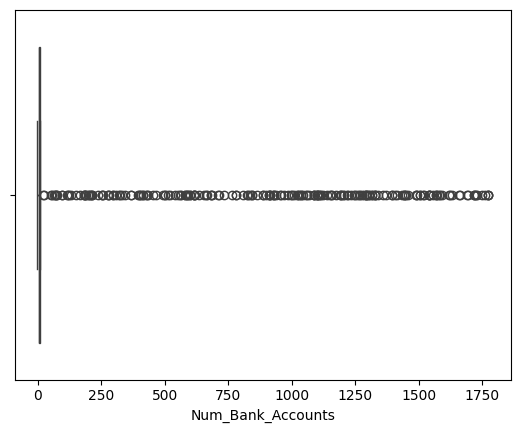

In [176]:
#From the above inspections it can be seen that the value 1727 appears on the column for number of bank accounts - this is an unexpected occurrence.

# The next is now to check for outliers.

import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df['Num_Bank_Accounts'])
plt.show()

In [177]:
#To further check for outliers - this method show us the minimum and maximum values in each column - we will pick columns that have out-of-range values and cure them. 

df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,16858.000000,1.685800e+04,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,16858.000000,1.685800e+04
mean,124.181398,1.513150e+05,4010.876638,16.827975,22.360778,70.348440,12.415411,22.033812,31.882252,10.759406,32.515364,32.192623,412.576106,1566.526646,626.584346,1.977301e+22
std,702.278797,1.237394e+06,3076.601647,115.105968,126.817349,455.818166,71.539110,15.153715,226.509357,6.794282,208.112627,5.067508,638.877057,8880.206201,2046.835062,2.567295e+24
min,14.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,1.000000,-5.000000,0.000000,0.010000,0.000000,21.248071,10.000000,4.462837,0.000000,1.034022e-01
25%,25.000000,1.883623e+04,1566.340671,4.000000,4.000000,8.000000,2.000000,11.000000,9.000000,5.520000,5.000000,28.008018,131.000000,42.869778,72.548515,2.641262e+02
50%,34.000000,3.622816e+04,2994.047083,6.000000,6.000000,15.000000,4.000000,19.000000,14.000000,9.660000,7.000000,32.218104,199.000000,83.824036,131.176610,3.250440e+02
75%,43.000000,6.985140e+04,5672.408333,8.000000,7.000000,22.000000,6.000000,29.000000,19.000000,15.340000,11.000000,36.362712,297.000000,181.342332,250.723979,4.471903e+02
max,8639.000000,2.399424e+07,15204.633333,1774.000000,1499.000000,5799.000000,1496.000000,67.000000,4343.000000,35.810000,2593.000000,47.288987,3311.000000,82398.000000,10000.000000,3.333333e+26


In [178]:
#First column - remove all entries where the number of bank accounts is not within the range of 0 to 15. 

df = df[df['Num_Bank_Accounts'].between(0, 15)]

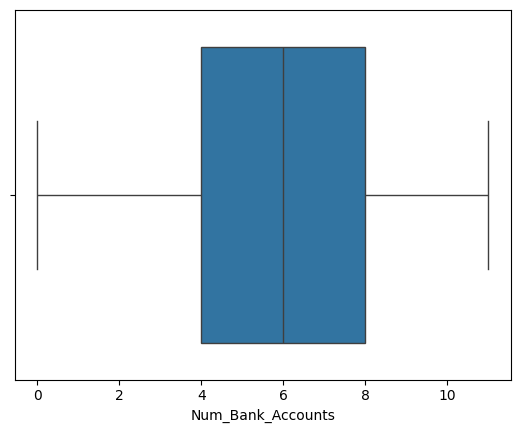

In [179]:
#Check that the step above worked - outliers were remmoved - the values are now normally distributed - centering on 6 bank accounts. 

sns.boxplot(x=df['Num_Bank_Accounts'])
plt.show()

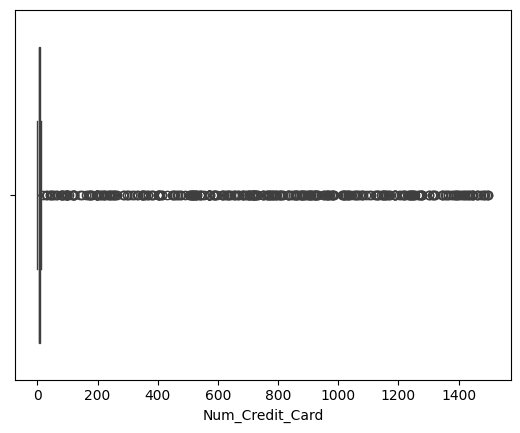

In [180]:
# Column 2: Check for outliers - present. 

sns.boxplot(x=df['Num_Credit_Card'])
plt.show()

In [181]:
#Column 2: remove outliers

df = df[df['Num_Credit_Card'] <= 15]

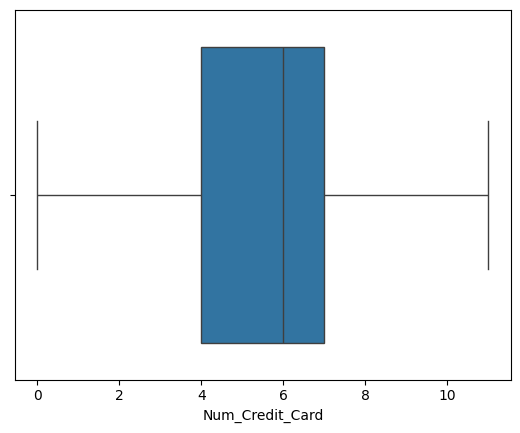

In [182]:
#Column 2: check that the outliers were removed - Yes. The data is now normally distributed with a slight skew.

sns.boxplot(x=df['Num_Credit_Card'])
plt.show()

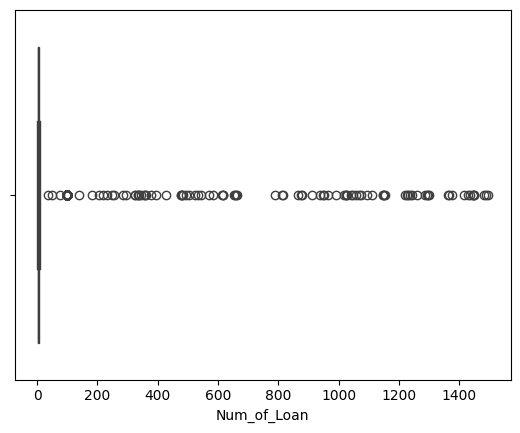

In [183]:
#Column 3: Check for outlier. 

sns.boxplot(x=df['Num_of_Loan'])
plt.show()

In [184]:
#Column 3: Remove outliers. 

df = df[df['Num_of_Loan'] <= 30]

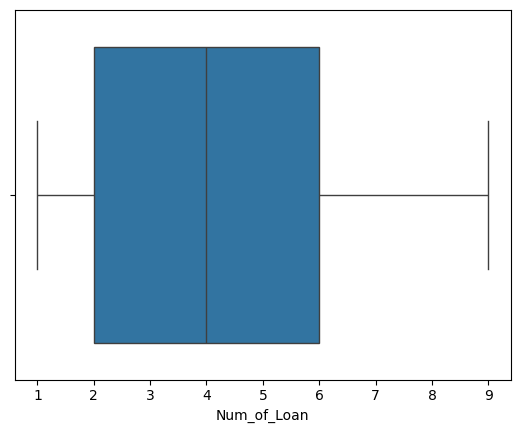

In [185]:
#Column 3: Check that the outliers were removed -  Yes. The data is now normally distributed with a slight skew. 

sns.boxplot(x=df['Num_of_Loan'])
plt.show()

In [186]:
#Check effect of these operations on the size of the dataset. 

df.shape

(15534, 20)

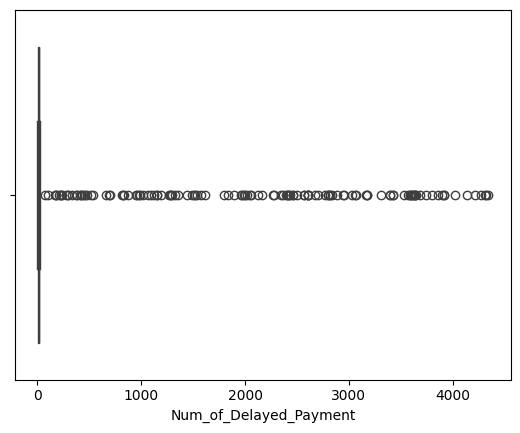

In [187]:
#Column 4: Check for outliers. 

sns.boxplot(x=df['Num_of_Delayed_Payment'])
plt.show()

In [188]:
#Column 4: remove outliers. 

df = df[df['Num_of_Delayed_Payment'] <= 50]


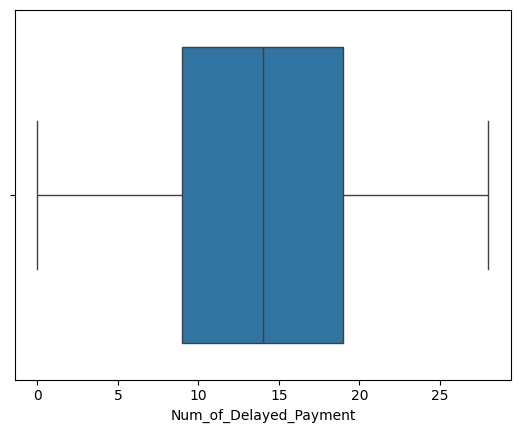

In [189]:
#Check that the outliers were removed - Yes - the data is now normally distributed arond the mean. 

sns.boxplot(x=df['Num_of_Delayed_Payment'])
plt.show()

In [190]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,15403.000000,1.540300e+04,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,15403.000000,1.540300e+04
mean,123.114134,1.466055e+05,4013.589668,5.527105,5.642862,70.777900,3.965656,22.033630,13.724080,10.740421,32.071350,32.193700,413.034539,1563.450211,625.819068,2.164081e+22
std,696.624331,1.208047e+06,3078.290013,2.586027,2.096651,458.182929,2.220170,15.154249,6.211009,6.783488,206.126094,5.071915,638.732063,8907.879920,2045.169959,2.685815e+24
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,1.000000,-5.000000,0.000000,0.010000,0.000000,21.248071,10.000000,4.462837,0.000000,1.034022e-01
25%,25.000000,1.879743e+04,1565.722083,4.000000,4.000000,8.000000,2.000000,11.000000,9.000000,5.530000,5.000000,28.008137,131.000000,43.047876,72.631201,2.641173e+02
50%,34.000000,3.631938e+04,2997.440000,6.000000,6.000000,15.000000,4.000000,19.000000,14.000000,9.660000,7.000000,32.217458,199.000000,83.723787,130.979151,3.248809e+02
75%,43.000000,6.989110e+04,5690.125833,8.000000,7.000000,22.000000,6.000000,29.000000,19.000000,15.300000,11.000000,36.374271,297.000000,181.316030,250.191637,4.476146e+02
max,8557.000000,2.399424e+07,15167.180000,11.000000,11.000000,5799.000000,9.000000,67.000000,28.000000,35.810000,2593.000000,47.288987,3311.000000,82398.000000,10000.000000,3.333333e+26


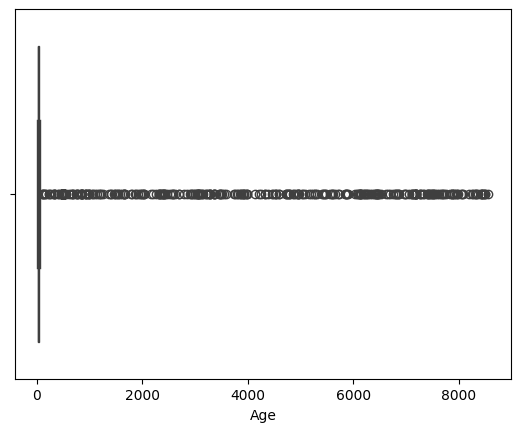

In [191]:
#Check for outliers in the age column.

sns.boxplot(x=df['Age'])
plt.show()

In [192]:
#Ensure that age does not stray beyond 90 years. 

df = df[df['Age'] <= 90]

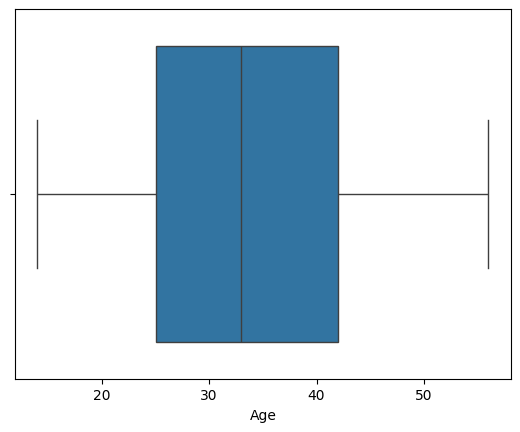

In [193]:
#Ascertain that age is now normalized and centrally distributed around the mean. 

sns.boxplot(x=df['Age'])
plt.show()

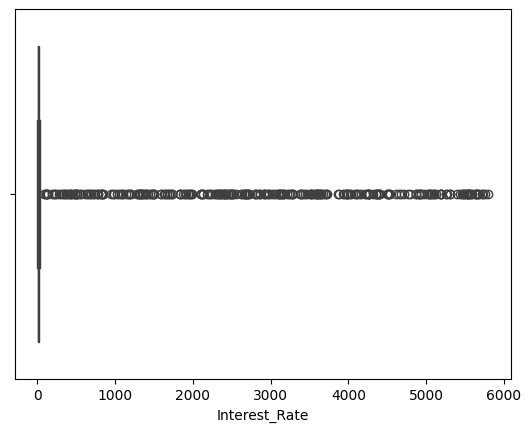

In [194]:
#Check for outliers in the interest rates.

sns.boxplot(x=df['Interest_Rate'])
plt.show()

In [195]:
#Remove outliers in the interests - ideal interest rates should not exceed 50%

df = df[df['Interest_Rate'] <= 60]

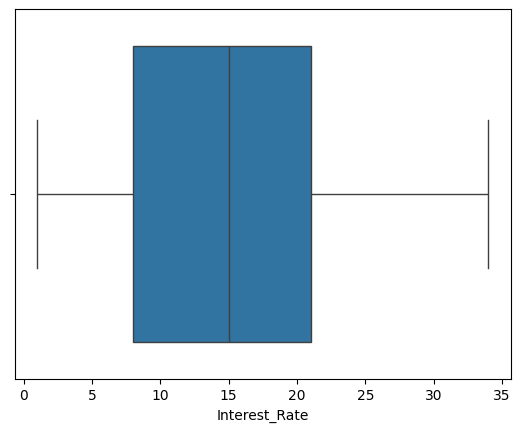

In [196]:
#Inspect outcome - interest rates are now normally distributed - centered on a 15% mean for the entire dataset. 

sns.boxplot(x=df['Interest_Rate'])
plt.show()

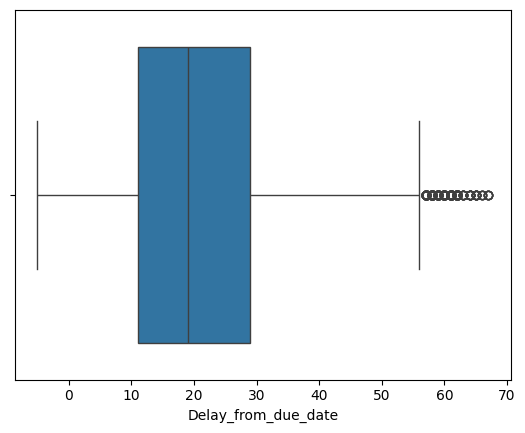

In [197]:
#From this outlier check, it can be seen that there are negative days as well as days beyond the 75th percentile. 

sns.boxplot(x=df['Delay_from_due_date'])
plt.show()

In [198]:
#We limit due date from 0 to 50 days.

df = df[df['Delay_from_due_date'].between(0, 50)]

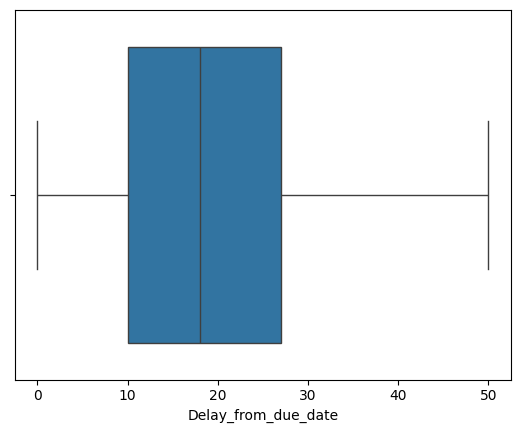

In [199]:
#On inspection, we can see that the outliers are no more and the data skews to the left. 

sns.boxplot(x=df['Delay_from_due_date'])
plt.show()

In [200]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,13452.000000,1.345200e+04,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,13452.000000,1.345200e+04
mean,33.741302,1.464879e+05,4115.373819,5.335117,5.490782,14.444246,3.796982,19.209634,13.267321,10.556389,32.127044,32.243562,426.320027,1544.564867,621.815419,2.477946e+22
std,10.752872,1.194945e+06,3140.575220,2.557222,2.050653,8.652388,2.150645,11.693541,6.145031,6.612644,207.628886,5.075404,654.277479,8808.806851,2027.101215,2.873990e+24
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.010000,0.000000,21.248071,10.000000,4.462837,0.000000,1.034022e-01
25%,25.000000,1.918111e+04,1594.946458,3.000000,4.000000,7.000000,2.000000,10.000000,9.000000,5.510000,4.000000,28.056974,140.000000,42.200797,73.674413,2.670471e+02
50%,33.000000,3.682229e+04,3043.080833,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.580000,7.000000,32.274358,204.000000,81.975439,133.468593,3.300354e+02
75%,42.000000,7.174668e+04,5873.433333,7.000000,7.000000,20.000000,5.000000,27.000000,18.000000,14.920000,10.000000,36.401375,301.000000,177.601891,255.593782,4.605986e+02
max,56.000000,2.399424e+07,15167.180000,11.000000,11.000000,34.000000,9.000000,50.000000,28.000000,35.810000,2593.000000,47.288987,3311.000000,82398.000000,10000.000000,3.333333e+26


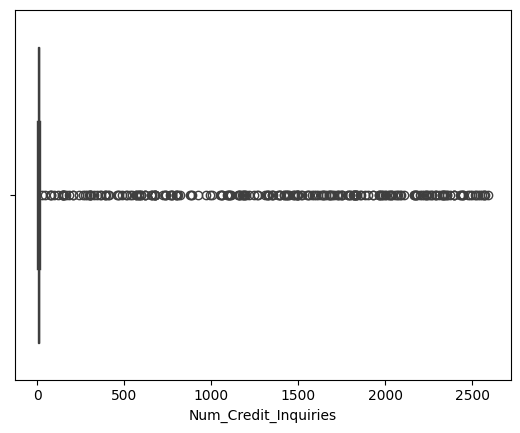

In [201]:
sns.boxplot(x=df['Num_Credit_Inquiries'])
plt.show()

In [202]:
df = df[df['Num_Credit_Inquiries'] <= 25]

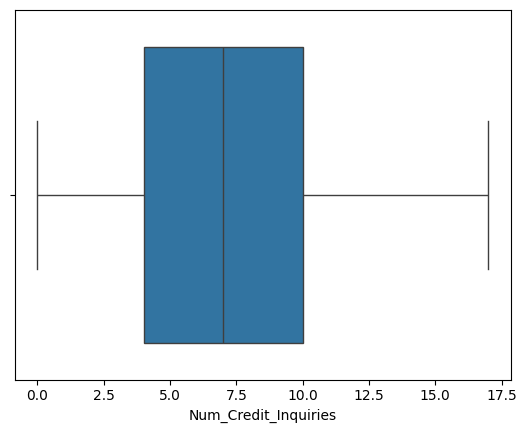

In [203]:
sns.boxplot(x=df['Num_Credit_Inquiries'])
plt.show()

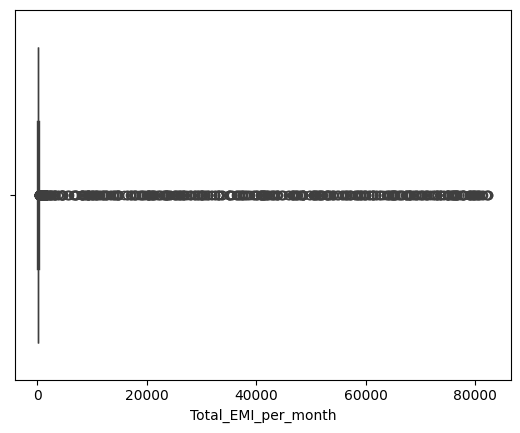

In [204]:
sns.boxplot(x=df['Total_EMI_per_month'])
plt.show()

In [205]:
df = df[df['Total_EMI_per_month'] <= 230]

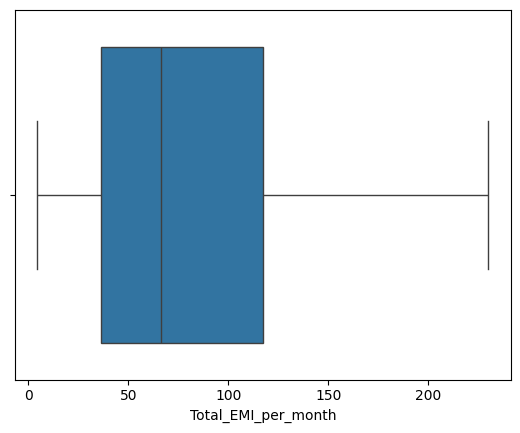

In [206]:
sns.boxplot(x=df['Total_EMI_per_month'])
plt.show()

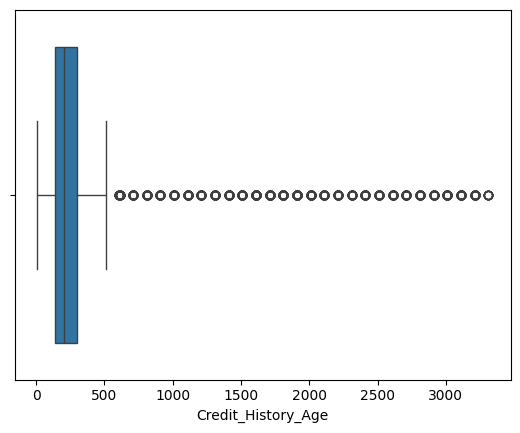

In [207]:
sns.boxplot(x=df['Credit_History_Age'])
plt.show()

In [222]:
df = df[df['Credit_History_Age'] <= 450]

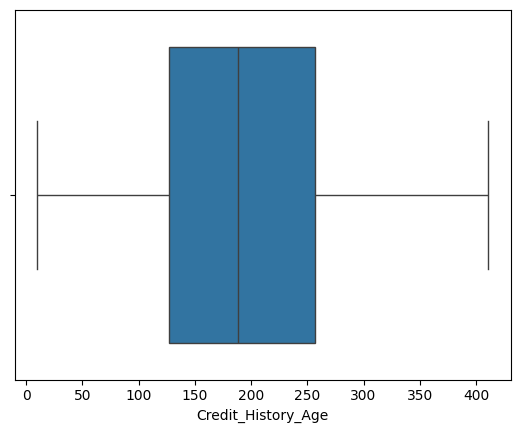

In [223]:
sns.boxplot(x=df['Credit_History_Age'])
plt.show()

In [210]:
df.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

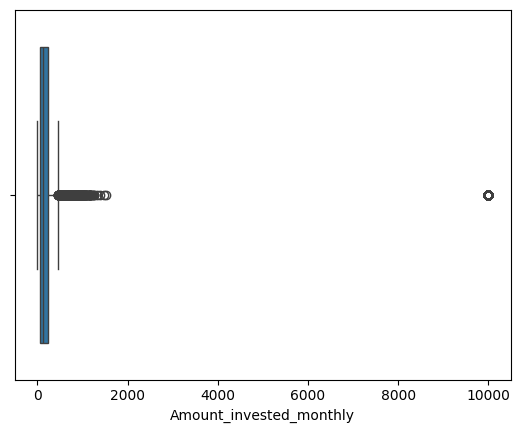

In [211]:
sns.boxplot(x=df['Amount_invested_monthly'])
plt.show()

In [214]:
df = df[df['Amount_invested_monthly'] <= 1000]

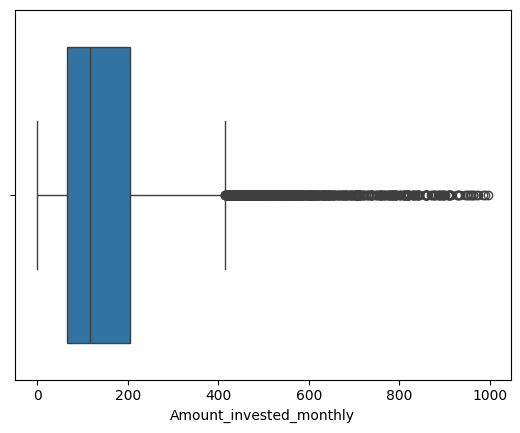

In [215]:
sns.boxplot(x=df['Amount_invested_monthly'])
plt.show()

In [216]:
df.shape

(8941, 20)

In [217]:
df = df[df['Amount_invested_monthly'] <= 650]

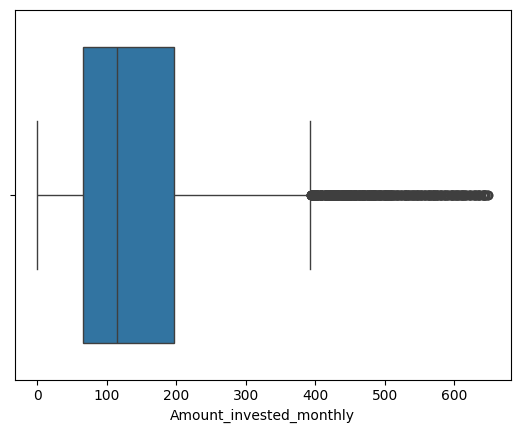

In [218]:
sns.boxplot(x=df['Amount_invested_monthly'])
plt.show()

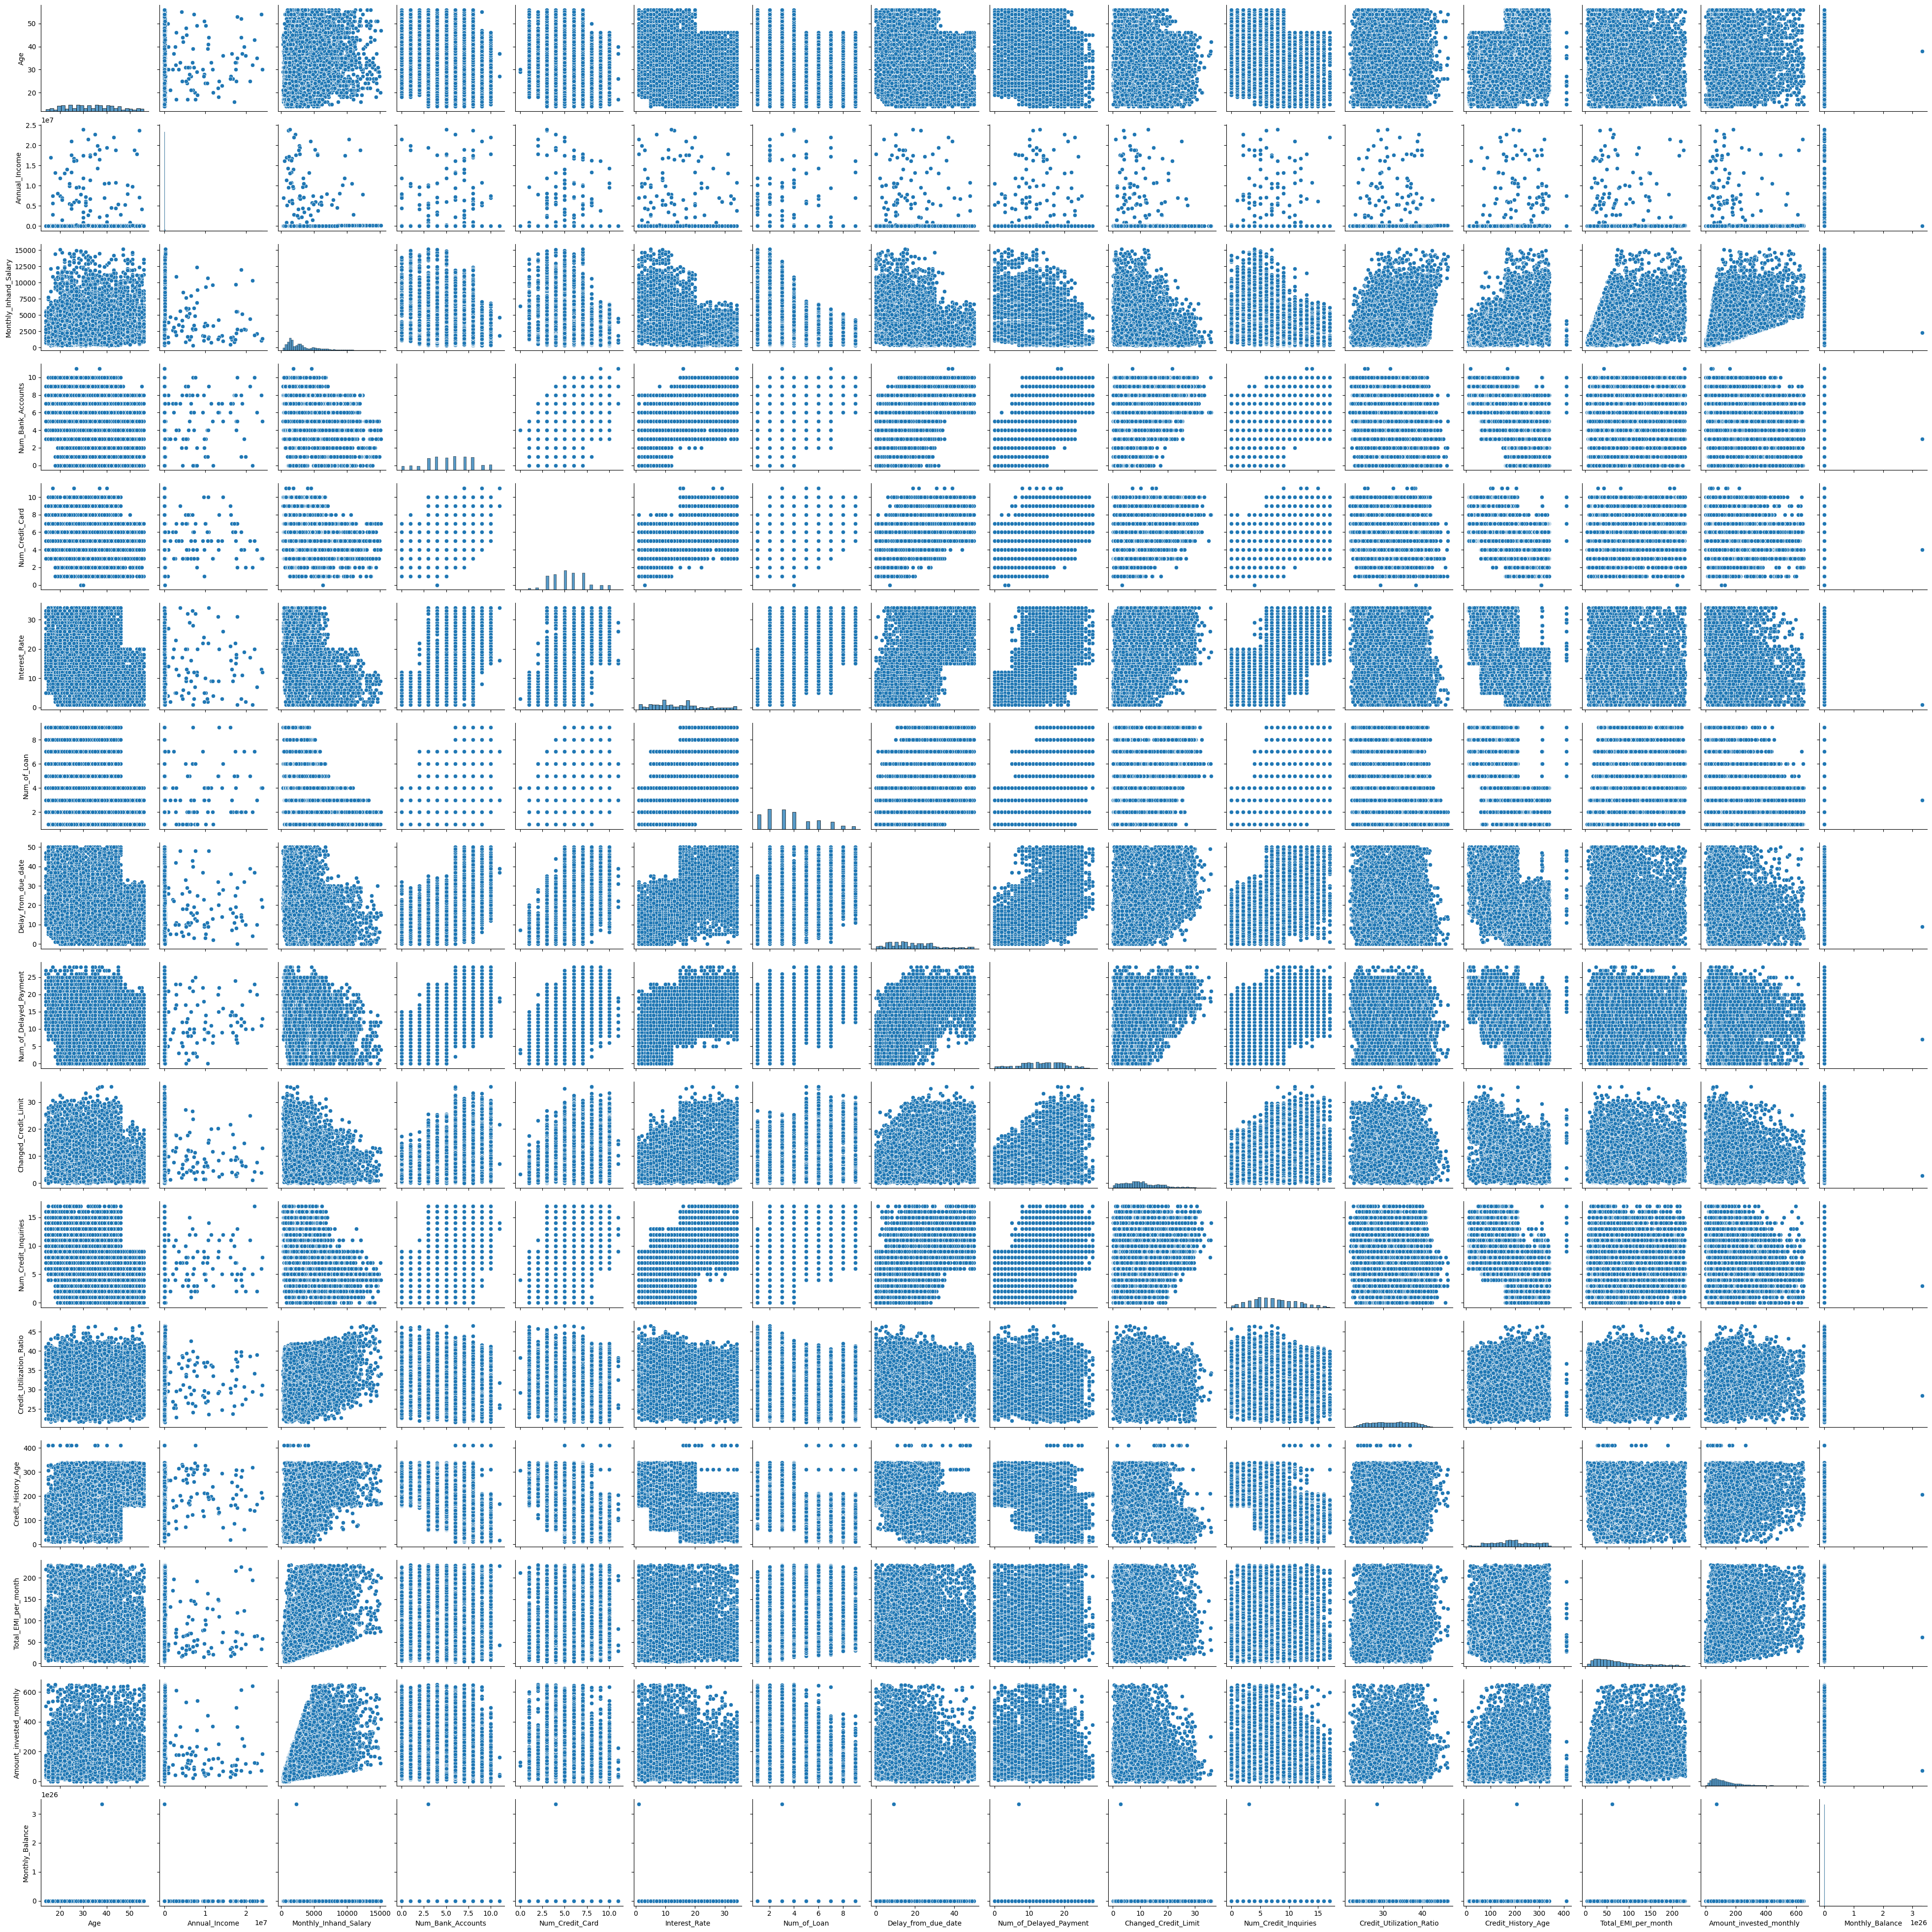

In [219]:
sns.pairplot(df)

plt.show()

In [220]:
df.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

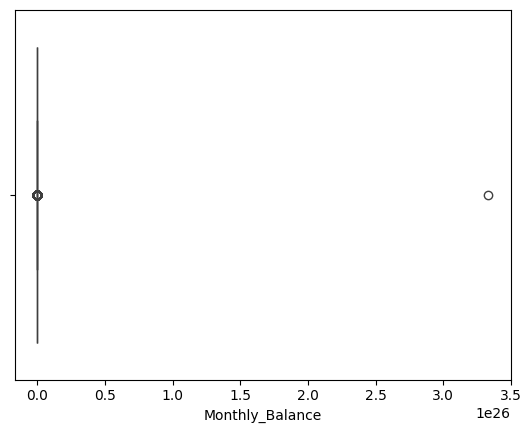

In [221]:
sns.boxplot(x=df['Monthly_Balance'])
plt.show()